In [1]:
# 1. IMPORT LIBRARIES & LOAD DATA
# ------------------------------------

from pathlib import Path
import warnings
import calendar

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras

import joblib
import json

# Setting Seaborn Theme
sns.set_theme(style="whitegrid", palette="muted")

# Setting path directory
ARTIFACT_ROOT = Path("/kaggle/working/streamintel360_artifacts") / "notebook_02_forecasting"

MODELS_DIR = ARTIFACT_ROOT / "models"
SCALERS_DIR = ARTIFACT_ROOT / "scalers"
METRICS_DIR = ARTIFACT_ROOT / "metrics"
FIGURES_DIR = ARTIFACT_ROOT / "figures"
METADATA_DIR = ARTIFACT_ROOT / "metadata"

# Create directories if they do not exist
for dir_path in [MODELS_DIR, SCALERS_DIR, METRICS_DIR, FIGURES_DIR, METADATA_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Assigning path to dataset
data_path = Path("/kaggle/input/datasets/hamaz911/electricity-csv/electricity.csv")

# Creating function to save figure in exact directory
def save_fig(fig_name):
    file_path = FIGURES_DIR / f"{fig_name}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print(f"Figure Saved: {file_path}")

# Loading dataset
data = pd.read_csv(data_path, parse_dates=[0], index_col=0)

# Sorting dataset and setting index
data = data.sort_index()
data.index.name = "Datetime"
data.index = pd.to_datetime(data.index)

# StreamIntel 360 Domain Mapping: Renaming single/target demand column to 'viewership_demand'
if len(data.columns) == 1:
    data.columns = ["viewership_demand"]
elif "Demand" in data.columns:
    data.rename(columns={"Demand": "viewership_demand"}, inplace=True)
elif "Value" in data.columns:
    data.rename(columns={"Value": "viewership_demand"}, inplace=True)

# Summary of dataset
print(f"Shape of Data   : {data.shape}")
print(f"Time Horizon    : {data.index.min()} ---> {data.index.max()}")

# Memory used by dataset
memory_used = data.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory Usage    : {memory_used:.2f} MB")

# Checking datatypes and non-null values
print("\nDataset Info:")
data.info()

print("\nDataset Head:")
display(data.head())

Shape of Data   : (140256, 370)
Time Horizon    : 2011-01-01 00:15:00 ---> 2015-01-01 00:00:00
Memory Usage    : 397.00 MB

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0 MB

Dataset Head:


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# 2. DATA CLEANING & PREPROCESSING
# ----------------------------------

# Selecting forecast mode and target column
forecast_mode = "aggregate"  # Options: "aggregate" (sum all streams/customers) or "single"
target_column = "MT_002"     # In case of single stream/customer column

# Resampling Frequency ----> "1h" for hourly viewership forecasting
resample_frequency = "1h"

# Checking missing values in rows and removing duplicate timestamps if present
print(f"Missing Values : {data.isnull().sum().sum()}")
duplicate_values = data.index.duplicated().sum()
print(f"Duplicate values : {duplicate_values}")
if duplicate_values > 0:
    data = data[~data.index.duplicated(keep="first")]
    print("Removed duplicated timestamps successfully.")

# Selecting target variable 
if forecast_mode == "single":
    if target_column not in data.columns:
        # Fallback if dataset has only 1 column from Cell 1 mapping
        target_column = data.columns[0]
    series = data[target_column].copy()
    series_name = f"Single Channel/Customer ({target_column})"
elif forecast_mode == "aggregate":
    series = data.sum(axis=1)
    series_name = "Total System Viewership Demand (All Streams)"
else:
    raise ValueError(f"Invalid forecast_mode: '{forecast_mode}'. Use 'aggregate' or 'single'")

print(f"Forecast Mode ---------> {forecast_mode.upper()}")
print(f"Forecast Target -------> {series_name}")
print(f"Observations ----------> {len(series):,}")

# Removing leading zero periods if present 
non_zero_index = series[series > 0].index

if len(non_zero_index) == 0:
    raise ValueError("The selected series has only zero values.")

series = series.loc[non_zero_index[0]:]
print(f"Current Time Horizon   : {series.index.min()} ---> {series.index.max()}")

# Resampling series to 1h time frame and forward filling missing gaps 
series = series.resample(resample_frequency).mean().ffill()

# Creating final dataframe aligned with StreamIntel 360 domain
forecast_df = pd.DataFrame({"viewership_demand": series})

print("DATA PREPROCESSING AND CLEANING SUMMARY")
print(f"Resample Frequency     : {resample_frequency}")
print(f"Final Observations     : {len(forecast_df):,}")
print(f"Missing Values         : {forecast_df.isnull().sum().sum()}")
print(f"Inferred Frequency     : {pd.infer_freq(forecast_df.index)}")
display(forecast_df.head())

Missing Values : 0
Duplicate values : 0
Forecast Mode ---------> AGGREGATE
Forecast Target -------> Total System Viewership Demand (All Streams)
Observations ----------> 140,256
Current Time Horizon   : 2011-01-01 00:15:00 ---> 2015-01-01 00:00:00
DATA PREPROCESSING AND CLEANING SUMMARY
Resample Frequency     : 1h
Final Observations     : 35,065
Missing Values         : 0
Inferred Frequency     : h


,viewership_demand
Datetime,
2011-01-01 00:00:00,69019.423424
2011-01-01 01:00:00,66344.627687
2011-01-01 02:00:00,65981.054883
2011-01-01 03:00:00,66576.533566
2011-01-01 04:00:00,64963.552675


Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure1_time_series_eda.png


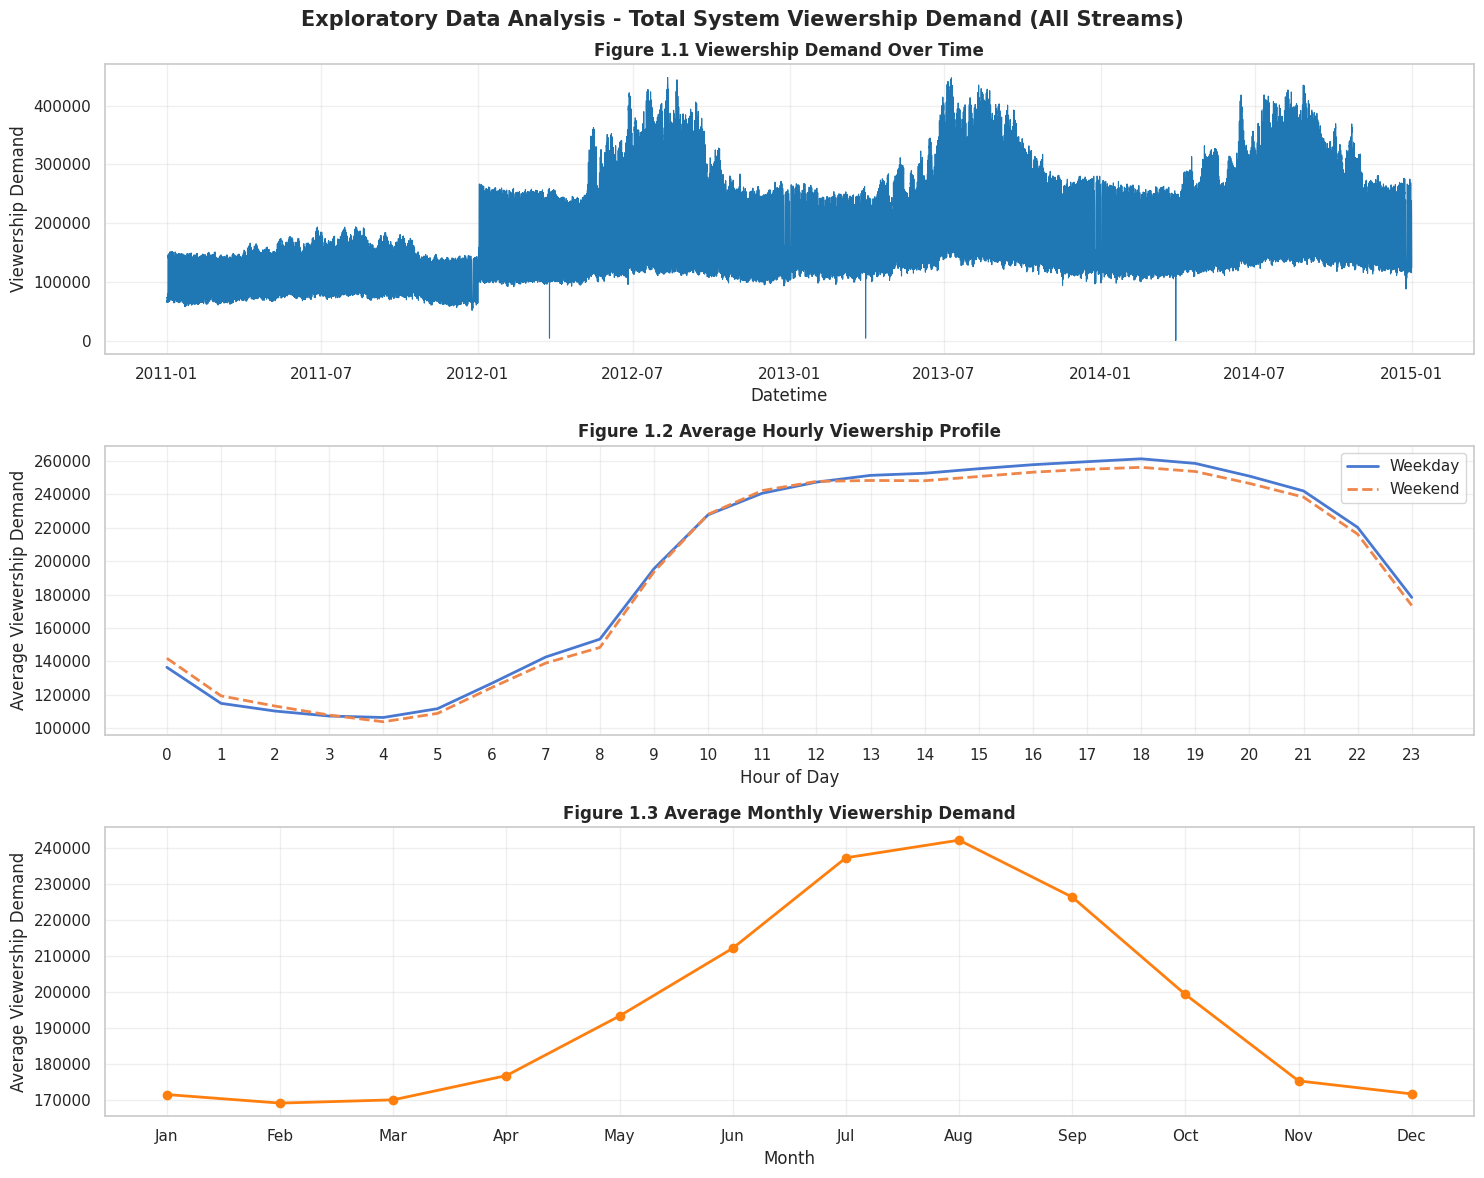

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure2_distribution_outliers.png


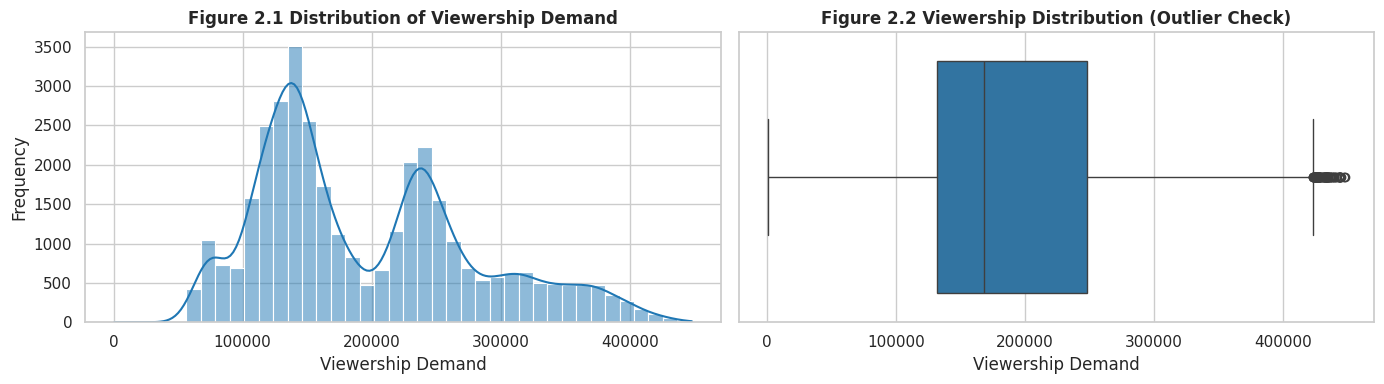

In [3]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------

demand_col = "viewership_demand" if "viewership_demand" in forecast_df.columns else "load_kW"

# Figure 1 - Trend, Daily Pattern & Monthly Seasonality
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle(f"Exploratory Data Analysis - {series_name}", fontsize=15, fontweight="bold", y=0.98)

# Plot 1 - Complete Time Series
axes[0].plot(forecast_df.index,forecast_df[demand_col],linewidth=0.8,color="#1f77b4")
axes[0].set_title("Figure 1.1 Viewership Demand Over Time", fontweight="bold")
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("Viewership Demand")
axes[0].grid(alpha=0.3)

# Plot 2 - Average Hourly Profile
eda_df = forecast_df.copy()

eda_df["Hour"] = eda_df.index.hour
eda_df["DayType"] = np.where(eda_df.index.dayofweek < 5,"Weekday","Weekend")
hourly_profile = (eda_df.groupby(["Hour", "DayType"])[demand_col].mean().unstack())
axes[1].plot(hourly_profile.index,hourly_profile["Weekday"],label="Weekday",linewidth=2)
axes[1].plot(hourly_profile.index,hourly_profile["Weekend"],label="Weekend",linewidth=2,linestyle="--")
axes[1].set_title("Figure 1.2 Average Hourly Viewership Profile", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Viewership Demand")
axes[1].set_xticks(range(24))
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3 - Monthly Seasonality
monthly_profile = (eda_df.groupby(eda_df.index.month)[demand_col].mean())
axes[2].plot(monthly_profile.index,monthly_profile.values,marker="o",linewidth=2,color="#ff7f0e")
axes[2].set_title("Figure 1.3 Average Monthly Viewership Demand", fontweight="bold")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Average Viewership Demand")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(calendar.month_abbr[1:])
axes[2].grid(alpha=0.3)
plt.tight_layout()
save_fig("figure1_time_series_eda")
plt.show()
plt.close()

# Figure 2 - Distribution & Outlier Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
sns.histplot(forecast_df[demand_col],bins=40,kde=True,ax=axes[0],color="#1f77b4")
axes[0].set_title("Figure 2.1 Distribution of Viewership Demand", fontweight="bold")
axes[0].set_xlabel("Viewership Demand")
axes[0].set_ylabel("Frequency")

# Boxplot
sns.boxplot(x=forecast_df[demand_col],ax=axes[1],color="#1f77b4")
axes[1].set_title("Figure 2.2 Viewership Distribution (Outlier Check)", fontweight="bold")
axes[1].set_xlabel("Viewership Demand")
plt.tight_layout()
save_fig("figure2_distribution_outliers")
plt.show()
plt.close()

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure3_rolling_statistics.png


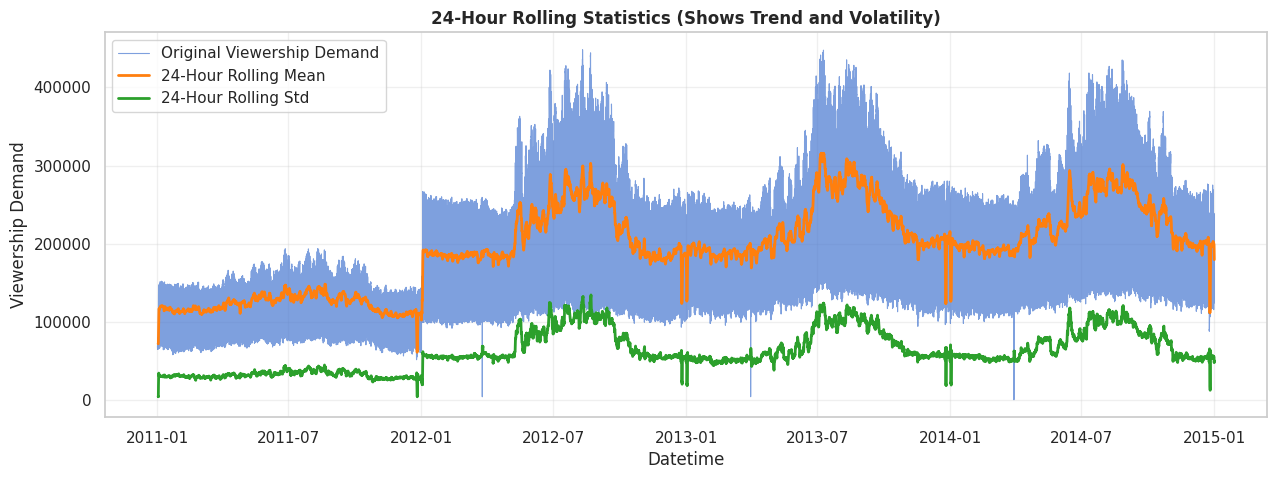


Augmented Dickey-Fuller Test
ADF Statistic : -3.0926
P-Value       : 0.027103
Critical values:
     1% : -3.4305
     5% : -2.8616
    10% : -2.5668
Result        : STATIONARY (p < 0.05)
Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure4_acf_pacf.png


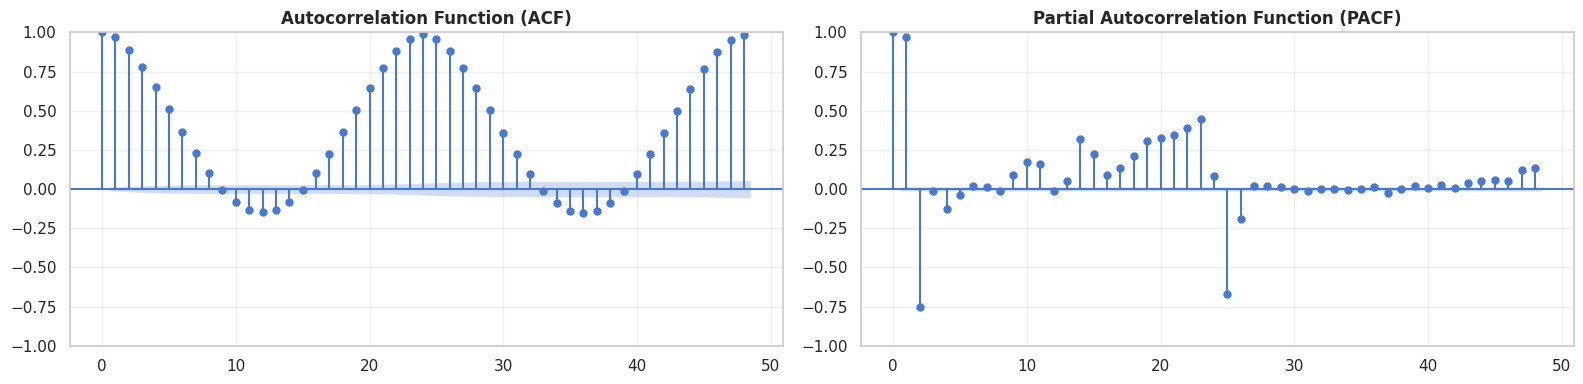

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure5_seasonal_decomposition.png


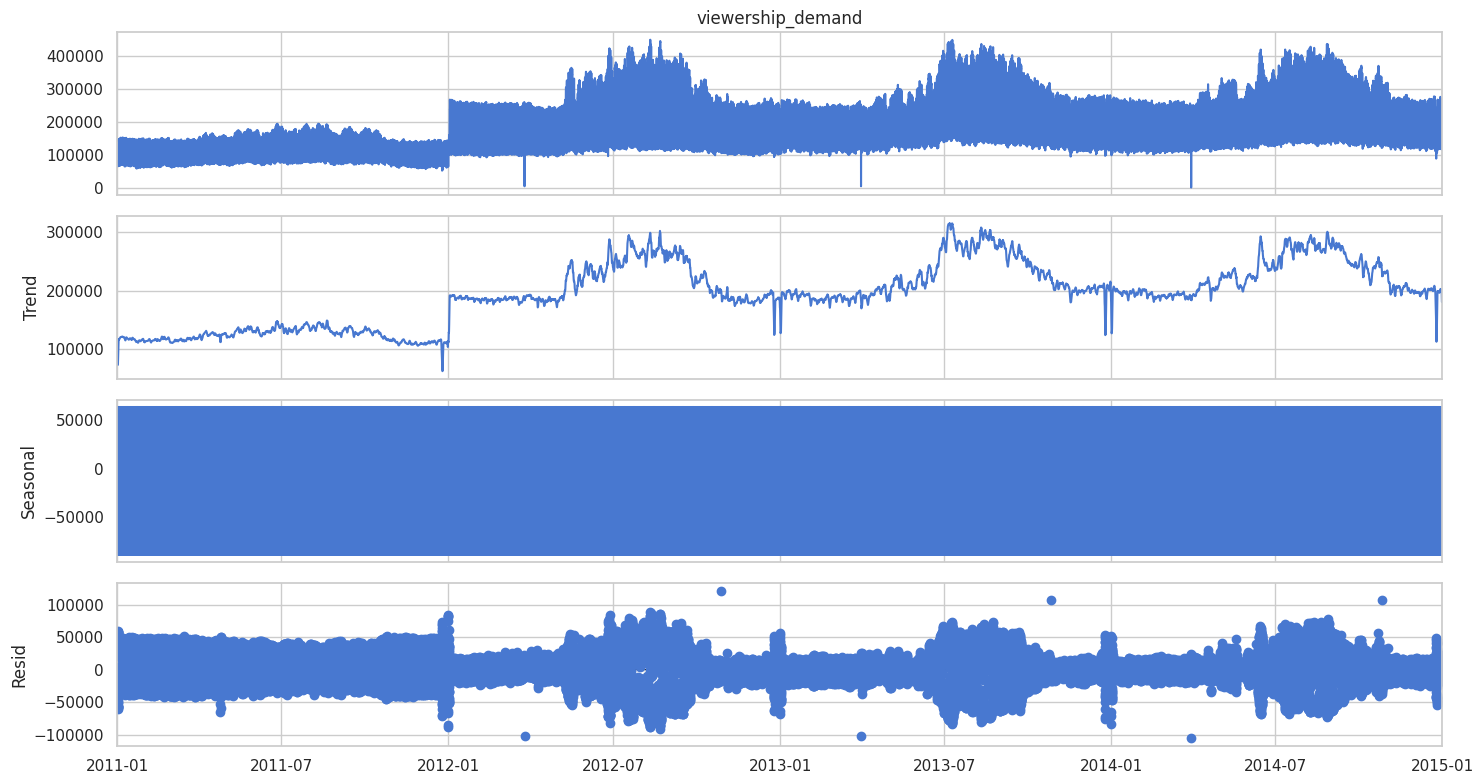

In [4]:
# 4. TIME SERIES ANALYSIS (TSA)
# -------------------------------

demand_col = "viewership_demand" if "viewership_demand" in forecast_df.columns else "load_kW"

# Figure 1 - Rolling Mean & Rolling Standard Deviation
rolling_mean = forecast_df[demand_col].rolling(window=24).mean()
rolling_std = forecast_df[demand_col].rolling(window=24).std()

plt.figure(figsize=(15, 5))

plt.plot(forecast_df.index, forecast_df[demand_col], label="Original Viewership Demand", linewidth=0.8, alpha=0.7)
plt.plot(rolling_mean, label="24-Hour Rolling Mean", linewidth=2, color="#ff7f0e")
plt.plot(rolling_std, label="24-Hour Rolling Std", linewidth=2, color="#2ca02c")

plt.title("24-Hour Rolling Statistics (Shows Trend and Volatility)", fontweight="bold")
plt.xlabel("Datetime")
plt.ylabel("Viewership Demand")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
save_fig("figure3_rolling_statistics")
plt.show()
plt.close()

# Creating Function for ADF Test to check whether Time Series is stationary
def adf_test(series):
    test = adfuller(series.dropna())
    print("\nAugmented Dickey-Fuller Test")
    print(f"ADF Statistic : {test[0]:.4f}")
    print(f"P-Value       : {test[1]:.6f}")

    print("Critical values:")
    for key, value in test[4].items():
        print(f"  {key:>5} : {value:.4f}")
    if test[1] < 0.05:
        print("Result        : STATIONARY (p < 0.05)")
    else:
        print("Result        : NON-STATIONARY (p >= 0.05)")
    return test

test_result = adf_test(forecast_df[demand_col])

# Figure 2 and 3 - Autocorrelation (ACF) & Partial ACF (PACF)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(forecast_df[demand_col], lags=48, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)", fontweight="bold")
axes[0].grid(True, alpha=0.3)

plot_pacf(forecast_df[demand_col], lags=48, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)", fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("figure4_acf_pacf")
plt.show()
plt.close()

# Figure 4 - Seasonal Decomposition (Additive, 24-Hour Period)
decomposition = seasonal_decompose(forecast_df[demand_col], model="additive", period=24)

fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.tight_layout()
save_fig("figure5_seasonal_decomposition")
plt.show()
plt.close()

In [5]:
# 5. FEATURE ENGINEERING 
# ----------------------------

# Dynamic target column check
target_column = "viewership_demand" if "viewership_demand" in forecast_df.columns else "load_kW"

# Creating Copy of dataset
featured_df = forecast_df.copy()

# Creating calendar, weekend, and month features
featured_df["hour"] = featured_df.index.hour
featured_df["day"] = featured_df.index.day
featured_df["day_of_week"] = featured_df.index.dayofweek
featured_df["month"] = featured_df.index.month
featured_df["year"] = featured_df.index.year

featured_df["is_weekend"] = (featured_df.index.dayofweek >= 5).astype(int)
featured_df["is_month_start"] = (featured_df.index.is_month_start).astype(int)
featured_df["is_month_end"] = (featured_df.index.is_month_end).astype(int)

# Creating cyclical features
featured_df["sin_hour"] = np.sin(2 * np.pi * featured_df["hour"] / 24)
featured_df["cos_hour"] = np.cos(2 * np.pi * featured_df["hour"] / 24)
featured_df["sin_month"] = np.sin(2 * np.pi * featured_df["month"] / 12)
featured_df["cos_month"] = np.cos(2 * np.pi * featured_df["month"] / 12)

# Creating lag features (1 hour, 24 hours, 1 week)
featured_df["lag_1"] = featured_df[target_column].shift(1)
featured_df["lag_24"] = featured_df[target_column].shift(24)
featured_df["lag_168"] = featured_df[target_column].shift(168)

# Creating rolling mean and std (Shifted by 1 to prevent data leakage)
featured_df["rolling_mean_24"] = (featured_df[target_column].shift(1).rolling(window=24).mean())
featured_df["rolling_std_24"] = (featured_df[target_column].shift(1).rolling(window=24).std())

# Removing missing values resulting from lag/rolling shifts
rows = len(featured_df)
featured_df.dropna(inplace=True)
dropped_rows = rows - len(featured_df)

# Summary of feature-engineered dataset
predictor_columns = [column for column in featured_df.columns if column != target_column]

print(f"Initial Rows     -----> {rows:,}")
print(f"Rows Removed     -----> {dropped_rows:,}")
print(f"Remaining Rows   -----> {len(featured_df):,}")
print(f"Dataset Shape    -----> {featured_df.shape}")
print(f"Target Variable  -----> {target_column}")
print(f"Predictors Count -----> {len(predictor_columns)}")

print("\nPredictor Features:")
for column in predictor_columns:
    print(f"  --> {column}")

# Feature-Engineered Dataset Preview
display(featured_df.head())

Initial Rows     -----> 35,065
Rows Removed     -----> 168
Remaining Rows   -----> 34,897
Dataset Shape    -----> (34897, 18)
Target Variable  -----> viewership_demand
Predictors Count -----> 17

Predictor Features:
  --> hour
  --> day
  --> day_of_week
  --> month
  --> year
  --> is_weekend
  --> is_month_start
  --> is_month_end
  --> sin_hour
  --> cos_hour
  --> sin_month
  --> cos_month
  --> lag_1
  --> lag_24
  --> lag_168
  --> rolling_mean_24
  --> rolling_std_24


,viewership_demand,hour,day,day_of_week,month,year,is_weekend,is_month_start,is_month_end,sin_hour,cos_hour,sin_month,cos_month,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
Datetime,,,,,,,,,,,,,,,,,,
2011-01-08 00:00:00,86403.301624,0,8,5,1,2011,1,0,0,0.000000,1.000000,0.5,0.866025,111609.594412,85716.807571,69019.423424,119987.091633,29802.024875
2011-01-08 01:00:00,72534.984171,1,8,5,1,2011,1,0,0,0.258819,0.965926,0.5,0.866025,86403.301624,73297.911807,66344.627687,120015.695552,29768.012259
2011-01-08 02:00:00,69325.030607,2,8,5,1,2011,1,0,0,0.500000,0.866025,0.5,0.866025,72534.984171,70543.526944,65981.054883,119983.906900,29820.431514
2011-01-08 03:00:00,68554.184257,3,8,5,1,2011,1,0,0,0.707107,0.707107,0.5,0.866025,69325.030607,70242.037536,66576.533566,119933.136219,29909.171077
2011-01-08 04:00:00,69033.522311,4,8,5,1,2011,1,0,0,0.866025,0.500000,0.5,0.866025,68554.184257,68884.017033,64963.552675,119862.809000,30032.821574


Sample Sizes:
Total Sample Size    : 34,897
Training Sample Size : 27,917 (80.00%)
Testing Sample Size  : 6,980 (20.00%)

Training Period:
Start : 2011-01-08 00:00:00
End   : 2014-03-16 04:00:00

Testing Period:
Start : 2014-03-16 05:00:00
End   : 2015-01-01 00:00:00

Featured Matrix Shapes:
X_train : (27917, 17)
X_test  : (6980, 17)

Target Vector Shapes:
y_train : (27917,)
y_test  : (6980,)
Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure6_train_test_split_horizon.png


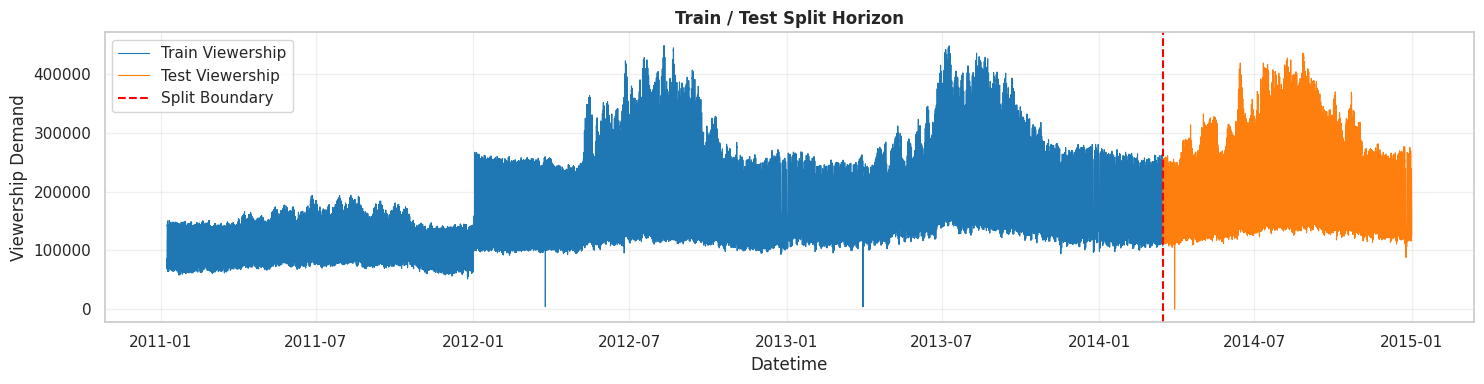

In [6]:
# 6. TRAIN/TEST SPLIT
# --------------------------

# Dynamic target column check
target_column = "viewership_demand" if "viewership_demand" in featured_df.columns else "load_kW"

# Defining splits X and y
X = featured_df.drop(columns=target_column)
y = featured_df[target_column]

# Splitting by ratio 80/20 (Chronological split for time series)
split_ratio = 0.80
split_index = int(len(featured_df) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Summary of split data
total_samples = len(featured_df)
train_pct = len(X_train) / total_samples
test_pct = len(X_test) / total_samples

print("Sample Sizes:")
print(f"Total Sample Size    : {total_samples:,}")
print(f"Training Sample Size : {len(X_train):,} ({train_pct:.2%})")
print(f"Testing Sample Size  : {len(X_test):,} ({test_pct:.2%})")

print("\nTraining Period:")
print(f"Start : {X_train.index.min()}")
print(f"End   : {X_train.index.max()}")

print("\nTesting Period:")
print(f"Start : {X_test.index.min()}")
print(f"End   : {X_test.index.max()}")

print("\nFeatured Matrix Shapes:")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

print("\nTarget Vector Shapes:")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

# Plot to show split boundary
plt.figure(figsize=(15, 4))
plt.plot(y_train.index, y_train, label="Train Viewership", color="#1f77b4", linewidth=0.8)
plt.plot(y_test.index, y_test, label="Test Viewership", color="#ff7f0e", linewidth=0.8)
plt.axvline(x=X_test.index.min(), color="red", linestyle="--", linewidth=1.5, label="Split Boundary")
plt.title("Train / Test Split Horizon", fontweight="bold")
plt.xlabel("Datetime")
plt.ylabel("Viewership Demand")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("figure6_train_test_split_horizon")
plt.show()
plt.close()

In [7]:
# 7. FEATURE SCALING
# ---------------------------------

# Dynamic target column check
target_column = "viewership_demand" if "viewership_demand" in featured_df.columns else "load_kW"

# Defining scalers for X features and target y
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler() 

# Fitting scalers on training data only to prevent data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Target Scaling
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Converting scaled X features back to DataFrame with original index & columns
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Converting scaled targets back to Series
y_train_scaled = pd.Series(y_train_scaled, index=y_train.index, name=target_column)
y_test_scaled = pd.Series(y_test_scaled, index=y_test.index, name=target_column)

# Saving scalers in central artifact repository for deployment
joblib.dump(scaler_X, SCALERS_DIR / "scaler_X.joblib")
joblib.dump(scaler_y, SCALERS_DIR / "scaler_y.joblib")

# Summary of scaled data
print(f"Scaled X_train Shape : {X_train_scaled.shape}")
print(f"Scaled X_test Shape  : {X_test_scaled.shape}")

print("\nScaled Feature Value Range:")
print(f"  Minimum Value : {X_train_scaled.min().min():.2f}")
print(f"  Maximum Value : {X_train_scaled.max().max():.2f}")
print(f"\nScalers saved successfully to: {SCALERS_DIR.resolve()}")
print("\nScaled X_train Preview:")

display(X_train_scaled.head())
print("\nScaled y_train Preview:")
display(y_train_scaled.head())

Scaled X_train Shape : (27917, 17)
Scaled X_test Shape  : (6980, 17)

Scaled Feature Value Range:
  Minimum Value : 0.00
  Maximum Value : 1.00

Scalers saved successfully to: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/scalers

Scaled X_train Preview:


,hour,day,day_of_week,month,year,is_weekend,is_month_start,is_month_end,sin_hour,cos_hour,sin_month,cos_month,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
Datetime,,,,,,,,,,,,,,,,,
2011-01-08 00:00:00,0.000000,0.233333,0.833333,0.0,0.0,1.0,0.0,0.0,0.500000,1.000000,0.75,0.933013,0.241793,0.183457,0.145839,0.230812,0.196008
2011-01-08 01:00:00,0.043478,0.233333,0.833333,0.0,0.0,1.0,0.0,0.0,0.629410,0.982963,0.75,0.933013,0.185004,0.155478,0.139813,0.230924,0.195746
2011-01-08 02:00:00,0.086957,0.233333,0.833333,0.0,0.0,1.0,0.0,0.0,0.750000,0.933013,0.75,0.933013,0.153759,0.149273,0.138994,0.230799,0.196149
2011-01-08 03:00:00,0.130435,0.233333,0.833333,0.0,0.0,1.0,0.0,0.0,0.853553,0.853553,0.75,0.933013,0.146527,0.148593,0.140335,0.230600,0.196830
2011-01-08 04:00:00,0.173913,0.233333,0.833333,0.0,0.0,1.0,0.0,0.0,0.933013,0.750000,0.75,0.933013,0.144791,0.145534,0.136701,0.230323,0.197779



Scaled y_train Preview:


Datetime
2011-01-08 00:00:00    0.185004
2011-01-08 01:00:00    0.153759
2011-01-08 02:00:00    0.146527
2011-01-08 03:00:00    0.144791
2011-01-08 04:00:00    0.145871
Freq: h, Name: viewership_demand, dtype: float64

Training Subset Horizon : 2014-02-14 05:00:00 --> 2014-03-16 04:00:00
Test Evaluation Steps   : 6,980 steps

Training ARIMA(2, 1, 2) --------->
---> Training completed successfully for ARIMA

Training SARIMA(1, 1, 1)x(1, 1, 1, 24) ------>
---> Training completed successfully for SARIMA

SUMMARY OF ARIMA AND SARIMA:


,Model,MAE,RMSE,MAPE
0,SARIMA,82481.602089,96979.591047,0.389607
1,ARIMA,126678.609757,151713.296137,0.511008


Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure7_classical_models_forecast_vs_actual.png


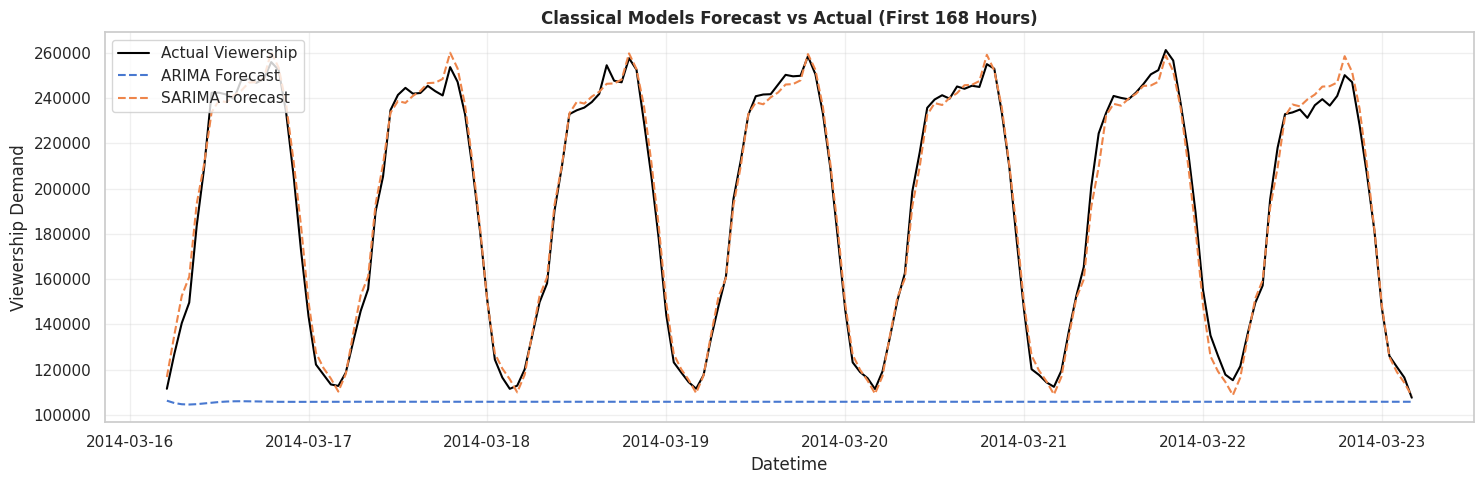

In [8]:
# 8. CLASSICAL FORECASTING MODELS (ARIMA AND SARIMA)
# --------------------------------------------------

# Creating function to evaluate models
def evaluate_forecast(model_name, y_actual, y_pred):
    """Calculate time series evaluation metrics."""
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_actual, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_actual, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_actual, y_pred)
    }

forecast_results = []
predictions_dict = {}

# Statistical models converge much faster when fitted on recent history
# Train window is last 30 days of training data
TRAIN_WINDOW = 24 * 30  # (24 hours x 30 days)
y_train_subset = y_train.iloc[-TRAIN_WINDOW:]

print(f"Training Subset Horizon : {y_train_subset.index.min()} --> {y_train_subset.index.max()}")
print(f"Test Evaluation Steps   : {len(y_test):,} steps")

# ARIMA MODEL
print("\nTraining ARIMA(2, 1, 2) --------->")

try:
    arima = ARIMA(y_train_subset, order=(2, 1, 2))
    arima_model = arima.fit()
    arima_predictions = arima_model.forecast(steps=len(y_test))
    
    # Storing predictions and evaluation
    predictions_dict["ARIMA"] = arima_predictions
    forecast_results.append(evaluate_forecast("ARIMA", y_test, arima_predictions))
    print("---> Training completed successfully for ARIMA")
except Exception as e:
    print(f"-> ARIMA failed: {e}")

# SARIMA MODEL
print("\nTraining SARIMA(1, 1, 1)x(1, 1, 1, 24) ------>")

try:
    sarima = SARIMAX(
        y_train_subset,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_model = sarima.fit(disp=False, maxiter=50)
    sarima_predictions = sarima_model.forecast(steps=len(y_test))
    
    # Storing predictions and evaluation
    predictions_dict["SARIMA"] = sarima_predictions
    forecast_results.append(evaluate_forecast("SARIMA", y_test, sarima_predictions))
    print("---> Training completed successfully for SARIMA")
except Exception as e:
    print(f"-> SARIMA failed: {e}")

# Creating dataframe of forecast results
forecast_results_df = (pd.DataFrame(forecast_results).sort_values("RMSE").reset_index(drop=True))

print("\nSUMMARY OF ARIMA AND SARIMA:")
display(forecast_results_df)

# Creating plot for predictions vs actual for 1 week (168 hours)
PLOT_HOURS = 168  
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:PLOT_HOURS], y_test.iloc[:PLOT_HOURS], label="Actual Viewership", color="black", linewidth=1.5)

for model_name, preds in predictions_dict.items():
    plt.plot(y_test.index[:PLOT_HOURS], preds.iloc[:PLOT_HOURS], label=f"{model_name} Forecast", linestyle="--", linewidth=1.5)

plt.title(f"Classical Models Forecast vs Actual (First {PLOT_HOURS} Hours)", fontweight="bold")
plt.xlabel("Datetime")
plt.ylabel("Viewership Demand")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("figure7_classical_models_forecast_vs_actual")
plt.show()
plt.close()

In [9]:
# 9. CREATE SEQUENCES FOR RNN / LSTM / GRU
# -----------------------------------------------

# Number of previous time steps used to predict the next value
WINDOW_SIZE = 24

# Defining function to create 3D sequences
def create_sequences(X, y, window_size):
    """Converts time series arrays into 3D samples suitable for RNN, LSTM, and GRU models."""
    X_arr = np.asarray(X)
    y_arr = np.asarray(y)

    X_sequences = []
    y_sequences = []

    for i in range(len(X_arr) - window_size):
        X_sequences.append(X_arr[i : i + window_size])
        y_sequences.append(y_arr[i + window_size])

    return np.array(X_sequences), np.array(y_sequences)

# Generating training sequences
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)

# Generating testing sequences (attaches the last WINDOW_SIZE samples from train set to avoid test step loss)
X_test_combined = np.vstack([np.asarray(X_train_scaled.iloc[-WINDOW_SIZE:]), np.asarray(X_test_scaled)])
y_test_combined = np.concatenate([np.asarray(y_train_scaled.iloc[-WINDOW_SIZE:]), np.asarray(y_test_scaled)])

X_test_seq, y_test_seq = create_sequences(X_test_combined, y_test_combined, WINDOW_SIZE)

# Summary of Sequences
print(f"Window Size -------------> {WINDOW_SIZE} Hours")
print(f"Training Sequences ------> {X_train_seq.shape}")  
print(f"Training Targets --------> {y_train_seq.shape}") 
print(f"Testing Sequences -------> {X_test_seq.shape}")  
print(f"Testing Targets ---------> {y_test_seq.shape}")

print("\nSequence Dimensions:")
print(f"Time Steps per Sequence -> {X_train_seq.shape[1]}")
print(f"Features per Time Step --> {X_train_seq.shape[2]}")

Window Size -------------> 24 Hours
Training Sequences ------> (27893, 24, 17)
Training Targets --------> (27893,)
Testing Sequences -------> (6980, 24, 17)
Testing Targets ---------> (6980,)

Sequence Dimensions:
Time Steps per Sequence -> 24
Features per Time Step --> 17


In [ ]:
# 10. TRAIN SEQUENCE MODELS (SimpleRNN, LSTM, GRU)
# --------------------------------------------------

# Setting reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Architecture builder per model type -- same shape, dropout, and dense
# head across all three; only the recurrent layer type changes.
def build_sequence_model(layer_class, name):
    return keras.Sequential([
        keras.layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        layer_class(64, activation="tanh", return_sequences=False),
        keras.layers.Dropout(0.20),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1)
    ], name=name)

SEQUENCE_MODELS = {
    "SimpleRNN": keras.layers.SimpleRNN,
    "LSTM": keras.layers.LSTM,
    "GRU": keras.layers.GRU,
}

trained_seq_models = {}
training_histories = {}

for model_name, layer_class in SEQUENCE_MODELS.items():
    print(f"\nTraining -------> {model_name}")

    model = build_sequence_model(layer_class, model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )

    checkpoint_path = MODELS_DIR / f"{model_name.lower()}_model.keras"
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=0),
        keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0),
    ]

    # validation_split takes the last 15% chronologically when shuffle=False,
    # which preserves temporal order for time-series validation.
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.15,
        epochs=50,
        batch_size=64,
        callbacks=callbacks,
        verbose=0,
        shuffle=False,
    )

    trained_seq_models[model_name] = model
    training_histories[model_name] = history

    best_val_loss = min(history.history["val_loss"])
    best_epoch = np.argmin(history.history["val_loss"]) + 1
    print(f"  Epochs Run     : {len(history.history['loss'])}")
    print(f"  Best Epoch     : {best_epoch}")
    print(f"  Best Val Loss  : {best_val_loss:.6f}")
    print(f"  Model Saved To : {checkpoint_path}")

print(f"\nAll {len(SEQUENCE_MODELS)} sequence models trained successfully.")


In [ ]:
# 11. EVALUATE SEQUENCE MODELS
# --------------------------------------------------

# Per-model plot color and saved figure name (keeps each model's chart distinct)
MODEL_PLOT_STYLE = {
    "SimpleRNN": {"color": "#1f77b4", "figure": "figure8_simple_rnn_forecast_vs_actual"},
    "LSTM": {"color": "#ff7f0e", "figure": "figure9_lstm_forecast_vs_actual"},
    "GRU": {"color": "#2ca02c", "figure": "figure10_gru_forecast_vs_actual"},
}

# NOTE: predictions_dict already holds ARIMA/SARIMA entries from Section 8 -- append to it, don't reset
eval_arrays = {}  # keeps each model's (actual, predicted) for the residual analysis step

for model_name, model in trained_seq_models.items():
    predictions_scaled = model.predict(X_test_seq, verbose=0).flatten()

    # Inverse transforming predictions back to original viewership scale
    predictions = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
    actual = scaler_y.inverse_transform(np.asarray(y_test_seq).reshape(-1, 1)).flatten()
    eval_arrays[model_name] = (actual, predictions)

    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mean_squared_error(actual, predictions))

    non_zero_mask = actual != 0
    mape = (
        np.mean(np.abs((actual[non_zero_mask] - predictions[non_zero_mask]) / actual[non_zero_mask])) * 100
        if non_zero_mask.sum() > 0 else np.nan
    )

    print(f"{model_name} PERFORMANCE EVALUATION")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.2f}%\n")

    forecast_results.append({"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape})
    predictions_dict[model_name] = pd.Series(predictions, index=y_test.index[:len(predictions)])

    # Plotting actual vs predicted viewership demand (first 168 hours / 1 week)
    test_index = y_test.index[:len(actual)]
    PLOT_HOURS = min(168, len(test_index))
    style = MODEL_PLOT_STYLE[model_name]

    plt.figure(figsize=(15, 5))
    plt.plot(test_index[:PLOT_HOURS], actual[:PLOT_HOURS], label="Actual Viewership", linewidth=1.5, color="black")
    plt.plot(test_index[:PLOT_HOURS], predictions[:PLOT_HOURS], label=f"{model_name} Forecast", linestyle="--", linewidth=1.5, color=style["color"])
    plt.title(f"{model_name} Forecast vs Actual (First {PLOT_HOURS} Hours)", fontweight="bold")
    plt.xlabel("Datetime")
    plt.ylabel("Viewership Demand")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(style["figure"])
    plt.show()
    plt.close()

# Unpacking SimpleRNN's arrays for the residual diagnostics step below
rnn_actual, rnn_predictions = eval_arrays["SimpleRNN"]
rnn_mae = mean_absolute_error(rnn_actual, rnn_predictions)

forecast_results_df = (pd.DataFrame(forecast_results).sort_values("RMSE").reset_index(drop=True))
print("Current Model Leaderboard:")
display(forecast_results_df)



MODEL PERFORMANCE RANKING LEADERBOARD


,Rank,Model,MAE,RMSE,MAPE
0,1,SimpleRNN,6693.494489,9719.842181,6.833277
1,2,GRU,12198.938685,16205.939481,9.173721
2,3,LSTM,15527.422195,20773.628904,11.050685
3,4,SARIMA,82481.602089,96979.591047,0.389607
4,5,ARIMA,126678.609757,151713.296137,0.511008


BEST FORECASTING MODEL SUMMARY
Model : SimpleRNN
MAE   : 6693.4945
RMSE  : 9719.8422
MAPE  : 6.83%
Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure11_final_model_comparison.png


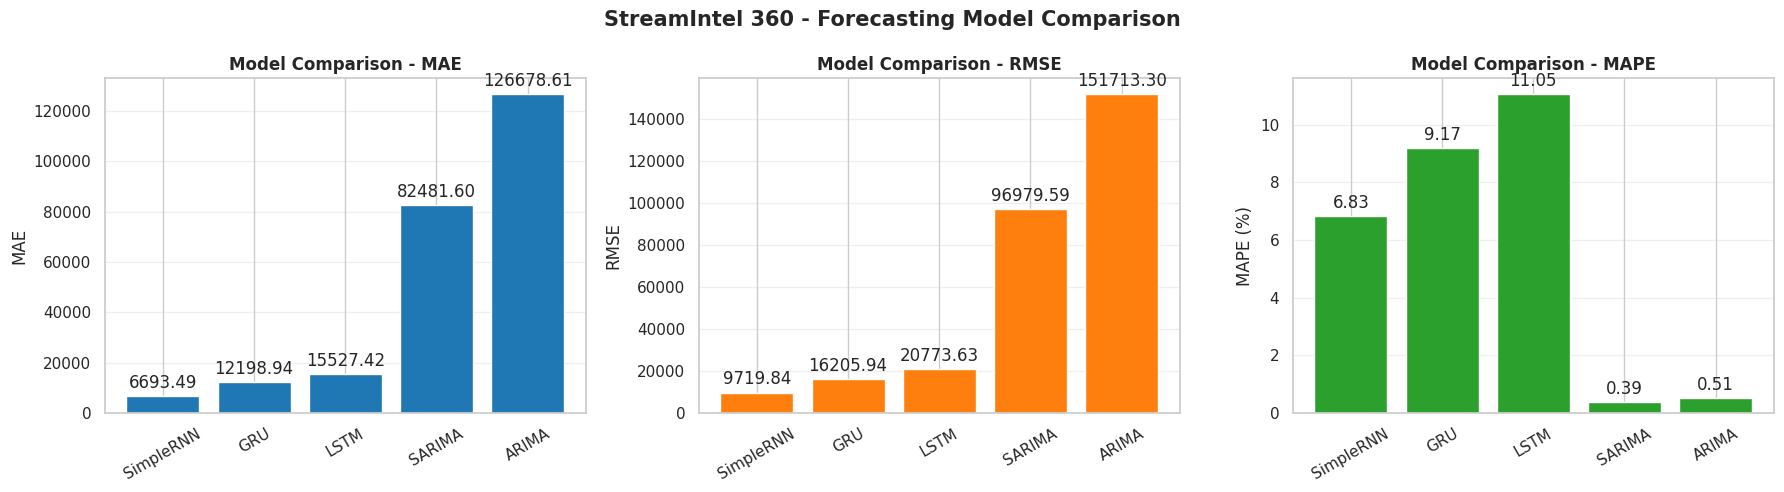

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure12_all_models_forecast_comparison.png


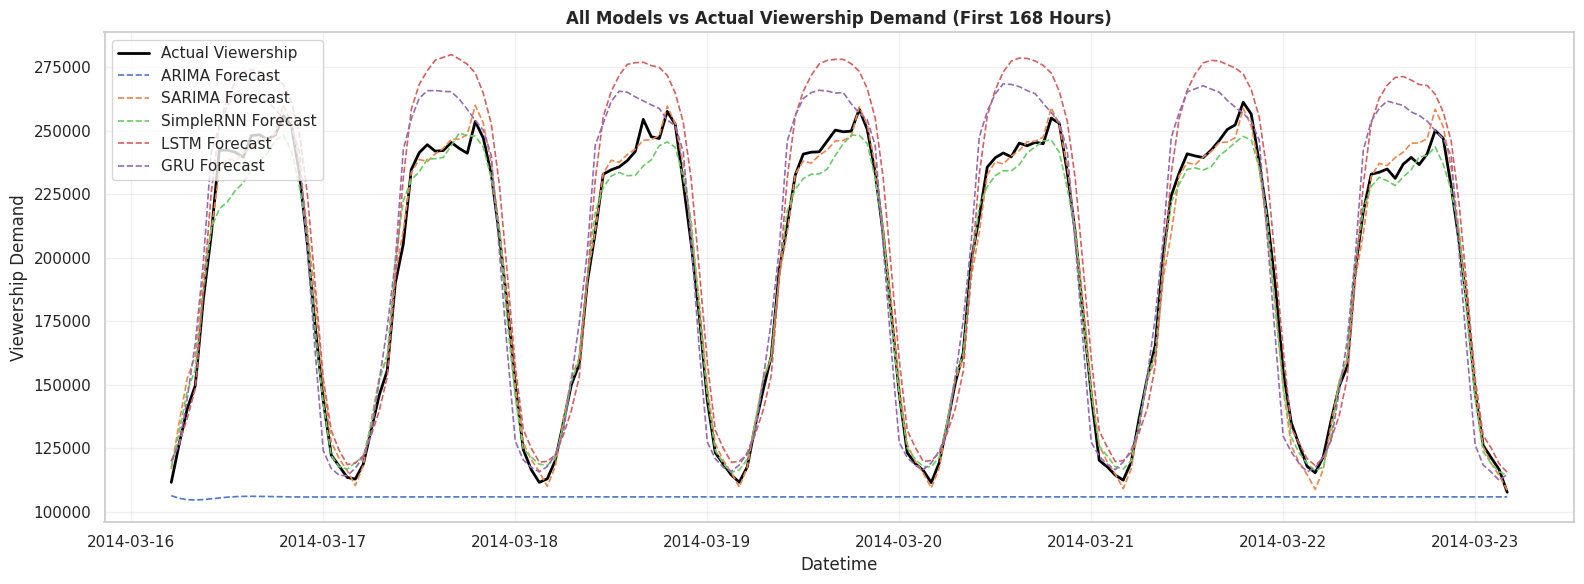


Final Results CSV Saved  : /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/metrics/final_forecasting_results.csv
Final Results JSON Saved : /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/metrics/model_comparison.json
Top Performer             : SimpleRNN
Lowest RMSE               : 9719.8422
Lowest MAE                : 6693.4945
Lowest MAPE               : 6.83%

Evaluated Pipeline Models:
 --> SimpleRNN
 --> GRU
 --> LSTM
 --> SARIMA
 --> ARIMA


In [ ]:
# 12. FINAL MODEL COMPARISON & LEADERBOARD
# ----------------------------------------

# Creating final results table 
final_results_df = (
    pd.DataFrame(forecast_results)
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

# Adding performance rank
final_results_df.insert(0, "Rank", range(1, len(final_results_df) + 1))

print("\n" + "=" * 50)
print("MODEL PERFORMANCE RANKING LEADERBOARD")
print("=" * 50)
display(final_results_df)

# Identifying overall best performing model
best_model = final_results_df.iloc[0]["Model"]
best_mae = final_results_df.iloc[0]["MAE"]
best_rmse = final_results_df.iloc[0]["RMSE"]
best_mape = final_results_df.iloc[0]["MAPE"]

print("BEST FORECASTING MODEL SUMMARY")
print(f"Model : {best_model}")
print(f"MAE   : {best_mae:.4f}")
print(f"RMSE  : {best_rmse:.4f}")
print(f"MAPE  : {best_mape:.2f}%")

# Bar chart metrics comparison across all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = final_results_df["Model"]

# MAE Comparison Chart
bars0 = axes[0].bar(models, final_results_df["MAE"], color="#1f77b4")
axes[0].set_title("Model Comparison - MAE", fontweight="bold")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)
axes[0].bar_label(bars0, fmt="%.2f", padding=3)

# RMSE Comparison Chart
bars1 = axes[1].bar(models, final_results_df["RMSE"], color="#ff7f0e")
axes[1].set_title("Model Comparison - RMSE", fontweight="bold")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)
axes[1].bar_label(bars1, fmt="%.2f", padding=3)

# MAPE Comparison Chart
bars2 = axes[2].bar(models, final_results_df["MAPE"], color="#2ca02c")
axes[2].set_title("Model Comparison - MAPE", fontweight="bold")
axes[2].set_ylabel("MAPE (%)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(axis="y", alpha=0.3)
axes[2].bar_label(bars2, fmt="%.2f", padding=3)

plt.suptitle("StreamIntel 360 - Forecasting Model Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig("figure11_final_model_comparison")
plt.show()
plt.close()

# Overlay Plot: Forecasts of All Models vs Actual Viewership Demand
actual_viewership = scaler_y.inverse_transform(np.asarray(y_test_seq).reshape(-1, 1)).flatten()
test_index = y_test.index[:len(actual_viewership)]
PLOT_HOURS = min(168, len(actual_viewership))

plt.figure(figsize=(16, 6))
plt.plot(test_index[:PLOT_HOURS], actual_viewership[:PLOT_HOURS], label="Actual Viewership", color="black", linewidth=2)

for model_name, predictions in predictions_dict.items():
    preds_arr = np.asarray(predictions).flatten()
    plt.plot(
        test_index[:PLOT_HOURS],
        preds_arr[:PLOT_HOURS],
        label=f"{model_name} Forecast",
        linewidth=1.2,
        linestyle="--"
    )

plt.title(f"All Models vs Actual Viewership Demand (First {PLOT_HOURS} Hours)", fontweight="bold")
plt.xlabel("Datetime")
plt.ylabel("Viewership Demand")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("figure12_all_models_forecast_comparison")
plt.show()
plt.close()

# Exporting final results to CSV and JSON within METRICS_DIR
csv_file = METRICS_DIR / "final_forecasting_results.csv"
json_file = METRICS_DIR / "model_comparison.json"

final_results_df.to_csv(csv_file, index=False)
final_results_df.to_json(json_file, orient="records", indent=4)

print(f"\nFinal Results CSV Saved  : {csv_file.resolve()}")
print(f"Final Results JSON Saved : {json_file.resolve()}")
print(f"Top Performer             : {best_model}")
print(f"Lowest RMSE               : {best_rmse:.4f}")
print(f"Lowest MAE                : {best_mae:.4f}")
print(f"Lowest MAPE               : {best_mape:.2f}%")

print("\nEvaluated Pipeline Models:")
for model in final_results_df["Model"]:
    print(f" --> {model}")

SIMPLERNN RESIDUAL SUMMARY STATISTICS
Mean Error (Bias) : 1911.8068
Std Deviation     : 9529.9699
Min Residual      : -124727.2232
Max Residual      : 131564.8683
Skewness          : 0.2274
Kurtosis          : 13.0846
Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/figures/figure13_simplernn_residual_analysis.png


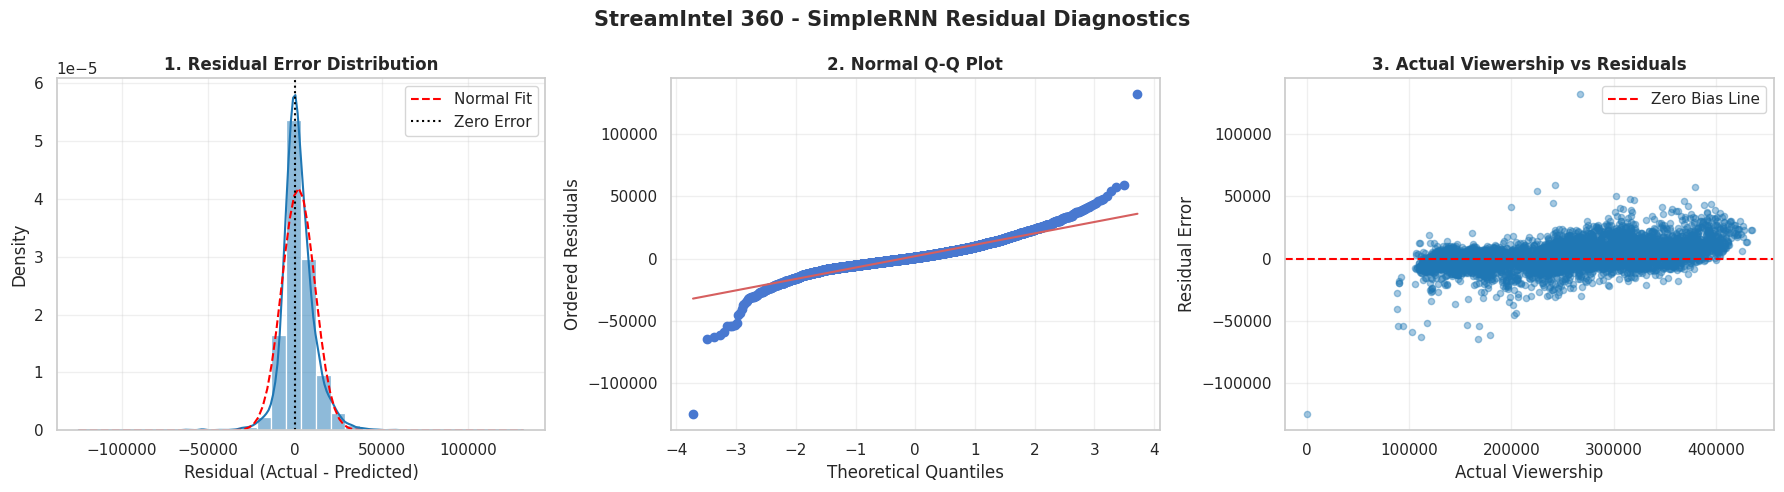

• Noticeable Prediction Bias: Mean residual error indicates systematic over/under-forecasting.
• Approximately Symmetric Errors: Residuals exhibit balanced variance around zero.
• Heavy/Light Tails (13.08): Outliers or extreme demand spikes affect prediction error.

SimpleRNN residual analysis completed successfully.


In [17]:
# 13. SIMPLERNN RESIDUAL ERROR ANALYSIS
# --------------------------------------------

# Calculating residual errors (Residual = Actual - Predicted)
residuals = rnn_actual - rnn_predictions

res_mean = np.mean(residuals)
res_std = np.std(residuals)
res_skew = stats.skew(residuals)
res_kurt = stats.kurtosis(residuals)

print("SIMPLERNN RESIDUAL SUMMARY STATISTICS")
print(f"Mean Error (Bias) : {res_mean:.4f}")
print(f"Std Deviation     : {res_std:.4f}")
print(f"Min Residual      : {np.min(residuals):.4f}")
print(f"Max Residual      : {np.max(residuals):.4f}")
print(f"Skewness          : {res_skew:.4f}")
print(f"Kurtosis          : {res_kurt:.4f}")

# Residual diagnostic plots (3-panel)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 - Residual Error Distribution
sns.histplot(residuals, kde=True, ax=axes[0], stat="density", bins=30, color="#1f77b4")

# Normal distribution reference fit
x_axis = np.linspace(np.min(residuals), np.max(residuals), 100)
axes[0].plot(
    x_axis,
    stats.norm.pdf(x_axis, res_mean, res_std),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Normal Fit"
)
axes[0].axvline(0, color="black", linestyle=":", linewidth=1.5, label="Zero Error")
axes[0].set_title("1. Residual Error Distribution", fontweight="bold")
axes[0].set_xlabel("Residual (Actual - Predicted)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 - Normal Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("2. Normal Q-Q Plot", fontweight="bold")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Ordered Residuals")
axes[1].grid(True, alpha=0.3)

# Plot 3 - Actual Viewership vs Residuals
axes[2].scatter(rnn_actual, residuals, alpha=0.4, s=20, color="#1f77b4")
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Bias Line")
axes[2].set_title("3. Actual Viewership vs Residuals", fontweight="bold")
axes[2].set_xlabel("Actual Viewership")
axes[2].set_ylabel("Residual Error")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("StreamIntel 360 - SimpleRNN Residual Diagnostics", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig("figure13_simplernn_residual_analysis")
plt.show()
plt.close()

# Bias evaluation relative to MAE
bias_ratio = abs(res_mean) / rnn_mae
if bias_ratio < 0.10:
    print("• Low Prediction Bias: Mean residual error is negligible relative to model MAE.")
else:
    print("• Noticeable Prediction Bias: Mean residual error indicates systematic over/under-forecasting.")

# Skewness evaluation
if abs(res_skew) < 0.5:
    print("• Approximately Symmetric Errors: Residuals exhibit balanced variance around zero.")
else:
    print(f"• Skewed Error Distribution ({res_skew:.2f}): Asymmetric prediction errors present.")

# Kurtosis evaluation
if abs(res_kurt) < 1.0:
    print("• Normal Tail Behavior: Residual distribution tails align closely with a normal distribution.")
else:
    print(f"• Heavy/Light Tails ({res_kurt:.2f}): Outliers or extreme demand spikes affect prediction error.")

print("\nSimpleRNN residual analysis completed successfully.")

In [18]:
# 14. BEST MODEL EXPORT & SERIALIZATION
# ----------------------------------------------

# Deployable deep learning models (trained in Section 10)
trained_models = trained_seq_models

# Filter results for exportable deep learning architectures
dl_results = final_results_df[final_results_df["Model"].isin(trained_models.keys())]

if dl_results.empty:
    raise ValueError("No matching neural network models found in final_results_df for serialization.")

# Selecting top performing neural network architecture based on RMSE
best_model_name = dl_results.loc[dl_results["RMSE"].idxmin(), "Model"]
best_model = trained_models[best_model_name]
best_model_row = dl_results[dl_results["Model"] == best_model_name].iloc[0]

print("DEPLOYMENT MODEL SELECTION")
print(f"Selected Model : {best_model_name}")
print(f"MAE            : {best_model_row['MAE']:.4f}")
print(f"RMSE           : {best_model_row['RMSE']:.4f}")
print(f"MAPE           : {best_model_row['MAPE']:.2f}%")

# Creating export directory structure within canonical MODELS_DIR
export_dir = MODELS_DIR / f"{best_model_name.lower()}_v1"
export_dir.mkdir(parents=True, exist_ok=True)

# Saving Keras Model
model_path = export_dir / f"{best_model_name.lower()}_model.keras"
best_model.save(model_path)

# Saving Scalers for Feature & Target Transformation
scaler_x_path = export_dir / "scaler_X.joblib"
scaler_y_path = export_dir / "scaler_y.joblib"

joblib.dump(scaler_X, scaler_x_path)
joblib.dump(scaler_y, scaler_y_path)

# Saving Pipeline & Production Configuration
config_metadata = {
    "project": "StreamIntel 360",
    "module": "Module 2 - Streaming Demand Forecasting",
    "model_name": best_model_name,
    "window_size_hours": int(WINDOW_SIZE),
    "target_variable": "viewership_demand",
    "input_features": list(X_train_scaled.columns),
    "number_of_features": len(X_train_scaled.columns),
    "metrics": {
        "MAE": float(best_model_row["MAE"]),
        "RMSE": float(best_model_row["RMSE"]),
        "MAPE_percent": float(best_model_row["MAPE"])
    }
}

config_path = export_dir / "pipeline_config.json"
with open(config_path, "w") as file:
    json.dump(config_metadata, file, indent=4)

# Saving model Comparison report
ranking_path = export_dir / "model_comparison.csv"
final_results_df.to_csv(ranking_path, index=False)

# Serialization summary 
print("\nMODEL SERIALIZATION & EXPORT COMPLETED")
print(f"Best Model       : {best_model_name}")
print(f"Export Path      : {export_dir.resolve()}")
print("\nSerialized Artifacts:")
print(f"  1. Model Weights    : {model_path.name}")
print(f"  2. Feature Scaler   : {scaler_x_path.name}")
print(f"  3. Target Scaler    : {scaler_y_path.name}")
print(f"  4. Config Metadata  : {config_path.name}")
print(f"  5. Leaderboard CSV  : {ranking_path.name}")

DEPLOYMENT MODEL SELECTION
Selected Model : SimpleRNN
MAE            : 6693.4945
RMSE           : 9719.8422
MAPE           : 6.83%

MODEL SERIALIZATION & EXPORT COMPLETED
Best Model       : SimpleRNN
Export Path      : /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/models/simplernn_v1

Serialized Artifacts:
  1. Model Weights    : simplernn_model.keras
  2. Feature Scaler   : scaler_X.joblib
  3. Target Scaler    : scaler_y.joblib
  4. Config Metadata  : pipeline_config.json
  5. Leaderboard CSV  : model_comparison.csv


In [19]:
# 15. REAL-TIME INFERENCE PIPELINE
# ----------------------------------------

# Filtering deployable deep learning models to locate top artifact
deployable_models = ["SimpleRNN", "LSTM", "GRU"]
dl_results = final_results_df[final_results_df["Model"].isin(deployable_models)]

if dl_results.empty:
    best_model_name = final_results_df.loc[final_results_df["RMSE"].idxmin(), "Model"]
else:
    best_model_name = dl_results.loc[dl_results["RMSE"].idxmin(), "Model"]

# Canonical export directory within MODELS_DIR
export_dir = MODELS_DIR / f"{best_model_name.lower()}_v1"

model_path = export_dir / f"{best_model_name.lower()}_model.keras"
scaler_x_path = export_dir / "scaler_X.joblib"
scaler_y_path = export_dir / "scaler_y.joblib"
config_path = export_dir / "pipeline_config.json"

print("[1/3] LOADING SERIALIZED PIPELINE ARTIFACTS")

# Loading saved model weights and scalers
loaded_model = keras.models.load_model(model_path)
loaded_scaler_X = joblib.load(scaler_x_path)
loaded_scaler_y = joblib.load(scaler_y_path)

# Loading pipeline configuration metadata
with open(config_path, "r") as file:
    config = json.load(file)

expected_features = config["input_features"]
expected_window = int(config["window_size_hours"])

print(f"Loaded Model Architecture : {config['model_name']}")
print(f"Lookback Window           : {expected_window} Hours")
print(f"Input Feature Count       : {len(expected_features)}")
print(f"Artifact Directory        : {export_dir.resolve()}")


# Production Inference Function
def predict_next_hour_demand(
    raw_sequence_df: pd.DataFrame,
    model: keras.Model,
    scaler_X,
    scaler_y,
    expected_window: int,
    expected_features: list
) -> float:
    """
    Processes a raw time-series sequence window and predicts single-step ahead viewership demand.
    """
    # Validating sequence row count matches expected lookback window
    if len(raw_sequence_df) != expected_window:
        raise ValueError(
            f"Input sequence must contain exactly {expected_window} rows. "
            f"Received {len(raw_sequence_df)} rows."
        )

    # Validating required feature presence
    missing_features = [
        feature for feature in expected_features
        if feature not in raw_sequence_df.columns
    ]
    if missing_features:
        raise ValueError(f"Missing required features: {missing_features}")

    # Enforcing exact training feature column order
    raw_sequence_df = raw_sequence_df[expected_features]

    # Scaling input features
    scaled_features = scaler_X.transform(raw_sequence_df)

    # Reshaping sequence to (1, lookback_window, num_features)
    input_tensor = np.expand_dims(scaled_features, axis=0)

    # Generating scaled inference prediction
    scaled_prediction = model.predict(input_tensor, verbose=0)

    # Inverse transforming prediction to original viewership scale
    predicted_demand = scaler_y.inverse_transform(scaled_prediction.reshape(-1, 1)).flatten()[0]
    return float(predicted_demand)


# Simulating real-time incoming data stream
print("\n[2/3] SIMULATING REAL-TIME INCOMING DATA STREAM")

# Use final training sequence window to predict first unseen test hour
sample_raw_sequence = X_train.iloc[-expected_window:].copy()

# Ground truth actual value for target hour
actual_next_hour_demand = float(y_test.iloc[0])

# Executing production inference
predicted_next_hour_demand = predict_next_hour_demand(
    raw_sequence_df=sample_raw_sequence,
    model=loaded_model,
    scaler_X=loaded_scaler_X,
    scaler_y=loaded_scaler_y,
    expected_window=expected_window,
    expected_features=expected_features
)

# Calculating forecast error metrics for test step
error_demand = abs(actual_next_hour_demand - predicted_next_hour_demand)
if actual_next_hour_demand != 0:
    pct_error = (error_demand / abs(actual_next_hour_demand)) * 100
else:
    pct_error = np.nan

# Displaying real-time forecast output
print("\n[3/3] REAL-TIME FORECAST OUTPUT & VALIDATION")
print(f"Input Horizon Start : {sample_raw_sequence.index[0]}")
print(f"Input Horizon End   : {sample_raw_sequence.index[-1]}")
print(f"Target Horizon      : {y_test.index[0]}")
print(f"Predicted Demand    : {predicted_next_hour_demand:,.2f}")
print(f"Actual Ground Truth : {actual_next_hour_demand:,.2f}")
print(f"Absolute Error      : {error_demand:,.2f}")
print(f"Percentage Error    : {pct_error:.2f}%")

print("\nProduction inference pipeline test passed successfully.")

[1/3] LOADING SERIALIZED PIPELINE ARTIFACTS
Loaded Model Architecture : SimpleRNN
Lookback Window           : 24 Hours
Input Feature Count       : 17
Artifact Directory        : /kaggle/working/streamintel360_artifacts/notebook_02_forecasting/models/simplernn_v1

[2/3] SIMULATING REAL-TIME INCOMING DATA STREAM

[3/3] REAL-TIME FORECAST OUTPUT & VALIDATION
Input Horizon Start : 2014-03-15 05:00:00
Input Horizon End   : 2014-03-16 04:00:00
Target Horizon      : 2014-03-16 05:00:00
Predicted Demand    : 117,521.77
Actual Ground Truth : 111,525.40
Absolute Error      : 5,996.37
Percentage Error    : 5.38%

Production inference pipeline test passed successfully.


In [ ]:
# NOTEBOOK 02 — ZIP ARTIFACT BACKUP
# ---------------------------------

from pathlib import Path
import shutil

ARTIFACT_ROOT = Path("/kaggle/working/streamintel360_artifacts/notebook_02_forecasting")
zip_base = Path("/kaggle/working/notebook_02_forecasting_backup")
zip_path = shutil.make_archive(str(zip_base),"zip",root_dir=ARTIFACT_ROOT)

print("NOTEBOOK 02 — ARTIFACT ZIP BACKUP")
print(f"\nSource Folder : {ARTIFACT_ROOT}")
print(f"ZIP File      : {zip_path}")

zip_size_mb = Path(zip_path).stat().st_size / (1024 * 1024)
print(f"ZIP Size      : {zip_size_mb:.2f} MB")


NOTEBOOK 02 — ARTIFACT ZIP BACKUP

Source Folder : /kaggle/working/streamintel360_artifacts/notebook_02_forecasting
ZIP File      : /kaggle/working/notebook_02_forecasting_backup.zip
ZIP Size      : 5.65 MB

✓ Notebook 02 artifacts successfully compressed.
✓ Download this ZIP to your laptop before the Kaggle session ends.
